# Bias in DAIC-WOZ — Google Colab Runner

**Before running:** Upload the 5 `.py` files directly into `MyDrive/DAIC/` (same folder as `AVEC_16_data`):
```
MyDrive/DAIC/
├── AVEC_16_data/          ← already uploaded ✓
│   ├── train_Ellie.txt
│   ├── train_Participant.txt
│   ├── dev_Ellie.txt
│   ├── dev_Participant.txt
│   ├── train_IDS.txt
│   └── dev_IDS.txt
├── 300_P/                 ← raw interview folders already there ✓
├── 301_P/ ...
├── main.py                ← upload these .py files here
├── baseline.py
├── eval_all_models.py
├── figure_1_heatmap.py
└── figure_2_color_interviews.py
```

Outputs (`output/`, `model/`, `plots/`) are saved back to Drive for persistence.

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configure Paths

Edit `DRIVE_DAIC_DIR` if your data folder is in a different location.

In [ ]:
import os

# Root of your DAIC folder on Drive — .py files and AVEC_16_data/ both live here
DRIVE_DAIC_DIR = '/content/drive/MyDrive/DAIC'

# Local working directory in Colab (fast storage)
WORK_DIR = '/content/bias-in-daic-woz'

# Verify Drive is accessible and has the expected folders
assert os.path.isdir(DRIVE_DAIC_DIR), (
    f"Cannot find {DRIVE_DAIC_DIR}. "
    "Make sure Drive is mounted and the folder name is correct."
)
assert os.path.isdir(f'{DRIVE_DAIC_DIR}/AVEC_16_data'), (
    f"Cannot find AVEC_16_data inside {DRIVE_DAIC_DIR}. "
    "Upload the AVEC_16_data/ folder there."
)

py_files = [f for f in os.listdir(DRIVE_DAIC_DIR) if f.endswith('.py')]
if not py_files:
    print("WARNING: No .py files found in", DRIVE_DAIC_DIR)
    print("Upload main.py, baseline.py, eval_all_models.py, figure_1_heatmap.py, figure_2_color_interviews.py there.")
else:
    print("Python files found:", py_files)

print("AVEC_16_data contents:", os.listdir(f'{DRIVE_DAIC_DIR}/AVEC_16_data'))

Python files found: ['figure_1_heatmap.py', 'figure_2_color_interviews.py', 'main.py', 'baseline.py', 'eval_all_models.py']
AVEC_16_data contents: ['dev_IDS.txt', 'train_IDS.txt', 'train_Ellie.txt', 'dev_Ellie.txt', 'dev_Participant.txt', 'train_Participant.txt']


## 3. Set Up Working Directory & Symlinks

In [ ]:
import shutil

os.makedirs(WORK_DIR, exist_ok=True)

# --- Copy .py files from Drive/DAIC/ into the working directory ---
py_files = [f for f in os.listdir(DRIVE_DAIC_DIR) if f.endswith('.py')]
for fname in py_files:
    shutil.copy(os.path.join(DRIVE_DAIC_DIR, fname), WORK_DIR)
print('Python files copied:', py_files)

# --- Symlink data/AVEC_16_data → Drive (read-only, already uploaded) ---
data_dir = os.path.join(WORK_DIR, 'data')
os.makedirs(data_dir, exist_ok=True)
avec_link = os.path.join(data_dir, 'AVEC_16_data')
if not os.path.exists(avec_link):
    os.symlink(f'{DRIVE_DAIC_DIR}/AVEC_16_data', avec_link)
print('data/AVEC_16_data ->', os.path.realpath(avec_link))

# --- Symlink output/, model/, plots/ → Drive so results persist ---
for subdir in ['output', 'model', 'plots']:
    drive_subdir = os.path.join(DRIVE_DAIC_DIR, subdir)
    os.makedirs(drive_subdir, exist_ok=True)
    link_path = os.path.join(WORK_DIR, subdir)
    if not os.path.exists(link_path):
        os.symlink(drive_subdir, link_path)
    print(f'{subdir}/ → {drive_subdir}')

print('\nWorking directory contents:', os.listdir(WORK_DIR))

Python files copied: ['figure_1_heatmap.py', 'figure_2_color_interviews.py', 'main.py', 'baseline.py', 'eval_all_models.py']
data/AVEC_16_data -> /content/drive/MyDrive/DAIC/AVEC_16_data
output/ → /content/drive/MyDrive/DAIC/output
model/ → /content/drive/MyDrive/DAIC/model
plots/ → /content/drive/MyDrive/DAIC/plots

Working directory contents: ['plots', 'eval_all_models.py', 'output', 'figure_2_color_interviews.py', 'model', 'figure_1_heatmap.py', 'baseline.py', 'main.py', 'data']


In [ ]:
# Change to working directory for all subsequent cells
%cd {WORK_DIR}

/content/bias-in-daic-woz


## 4. Install Dependencies

In [ ]:
# Install required packages
!pip install -q optuna scikit-learn scipy matplotlib nltk tqdm
!pip install -q transformers "datasets<3.0.0"

# Colab already has PyTorch, but ensure we have a GPU-compatible version
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 7.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
PyTorch version: 2.11.0+cpu
CUDA available: False


In [ ]:
# Download NLTK data required by main.py
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 5. Verify Data Files

In [ ]:
expected_files = [
    'data/AVEC_16_data/train_Ellie.txt',
    'data/AVEC_16_data/dev_Ellie.txt',
    'data/AVEC_16_data/train_Participant.txt',
    'data/AVEC_16_data/dev_Participant.txt',
    'data/AVEC_16_data/dev_IDS.txt',
]
all_ok = True
for f in expected_files:
    exists = os.path.isfile(f)
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {f}')
    all_ok = all_ok and exists

if all_ok:
    print('\nAll data files found. Ready to run.')
else:
    print('\nSome files are missing. Check your Drive structure.')

  [OK] data/AVEC_16_data/train_Ellie.txt
  [OK] data/AVEC_16_data/dev_Ellie.txt
  [OK] data/AVEC_16_data/train_Participant.txt
  [OK] data/AVEC_16_data/dev_Participant.txt
  [OK] data/AVEC_16_data/dev_IDS.txt

All data files found. Ready to run.


## 5b. Build Training & Dev Text Files from Raw Transcripts\n\nThe `train_Ellie.txt`, `dev_Ellie.txt`, `train_Participant.txt`, `dev_Participant.txt` files\nshipped with the repo are **placeholder stubs** (2 fake lines each — license restriction).\n\nRun this cell **once** to build the real files from your DAIC-WOZ transcript CSVs in Drive.\nIt reads every `<ID>_P/<ID>_TRANSCRIPT.csv`, concatenates speaker utterances per interview,\nand maps PHQ-8 scores to `positive` (depressed) / `negative` (control) labels.

In [ ]:
import os, re
import pandas as pd

# Raw interview folders live here (e.g. 300_P/300_TRANSCRIPT.csv)
DAIC_RAW_DIR = DRIVE_DAIC_DIR   # /content/drive/MyDrive/DAIC

# Output txt files go into the symlinked AVEC_16_data folder
AVEC_DIR = 'data/AVEC_16_data'

LABEL_MAP = {0: 'negative', 1: 'positive'}

def clean_utterance(text):
    """Remove XML-style tags and normalize whitespace."""
    text = re.sub(r'<[^>]+>', '', str(text))
    return ' '.join(text.split()).strip()

def build_split_files(ids_file, ellie_out, participant_out, split_name):
    ids_df = pd.read_csv(ids_file, sep='\t')
    ellie_lines, participant_lines = [], []
    missing, ok = [], []

    for _, row in ids_df.iterrows():
        pid   = int(row['original_ID'])
        label = LABEL_MAP[int(row['category'])]
        transcript_path = os.path.join(DAIC_RAW_DIR, f'{pid}_P', f'{pid}_TRANSCRIPT.csv')

        if not os.path.isfile(transcript_path):
            missing.append(pid)
            continue

        df = pd.read_csv(transcript_path, sep='\t')
        df.fillna('', inplace=True)
        df['speaker'] = df['speaker'].str.strip().str.lower()
        df['value']   = df['value'].map(clean_utterance)

        ellie_text       = ' '.join(df[df['speaker'] == 'ellie']['value'].tolist())
        participant_text = ' '.join(df[df['speaker'] == 'participant']['value'].tolist())

        ellie_lines.append(f'{label}\t{ellie_text}')
        participant_lines.append(f'{label}\t{participant_text}')
        ok.append(pid)

    with open(ellie_out, 'w', encoding='utf-8') as f:
        f.write('\n'.join(ellie_lines))
    with open(participant_out, 'w', encoding='utf-8') as f:
        f.write('\n'.join(participant_lines))

    print(f'[{split_name}] Written {len(ok)} interviews.')
    if missing:
        print(f'  WARNING: {len(missing)} transcript(s) not found: {missing[:10]}{"..." if len(missing)>10 else ""}')
    return len(ok), len(missing)

print('Building train files...')
ok_tr, miss_tr = build_split_files(
    f'{AVEC_DIR}/train_IDS.txt',
    f'{AVEC_DIR}/train_Ellie.txt',
    f'{AVEC_DIR}/train_Participant.txt',
    'TRAIN'
)

print('Building dev files...')
ok_dev, miss_dev = build_split_files(
    f'{AVEC_DIR}/dev_IDS.txt',
    f'{AVEC_DIR}/dev_Ellie.txt',
    f'{AVEC_DIR}/dev_Participant.txt',
    'DEV'
)

total_ok, total_miss = ok_tr + ok_dev, miss_tr + miss_dev
print(f'\nDone. {total_ok} interviews processed, {total_miss} missing transcripts.')
if total_miss > 0:
    print('Missing transcripts mean those participants are skipped.')
    print('Check that the folders exist at:', DAIC_RAW_DIR)

# Quick sanity check: show label distribution
for fname in ['train_Ellie.txt', 'dev_Ellie.txt', 'train_Participant.txt', 'dev_Participant.txt']:
    path = f'{AVEC_DIR}/{fname}'
    lines = open(path, encoding='utf-8').read().strip().split('\n')
    pos = sum(1 for l in lines if l.startswith('positive'))
    neg = sum(1 for l in lines if l.startswith('negative'))
    print(f'  {fname}: {len(lines)} total  |  positive={pos}  negative={neg}')

Building train files...
[TRAIN] Written 107 interviews.
Building dev files...
[DEV] Written 35 interviews.

Done. 142 interviews processed, 0 missing transcripts.
  train_Ellie.txt: 107 total  |  positive=30  negative=77
  dev_Ellie.txt: 35 total  |  positive=12  negative=23
  train_Participant.txt: 107 total  |  positive=30  negative=77
  dev_Participant.txt: 35 total  |  positive=12  negative=23


## 6. Run InducT-GCN Training (`main.py`)

Available task IDs (pass `-i <ID>` to select one):

| ID | Dataset | Features | PageRank |
|----|---------|----------|----------|
| 1  | Ellie | all | No |
| 2  | Ellie | auto (LR selector) | No |
| 3  | Ellie | top-250 | No |
| 4  | Participant | all | No |
| 5  | Participant | auto | No |
| 6  | Participant | top-250 | No |
| 7–12 | same as 1–6 but with PageRank |

Run without `-i` first to see the full list.

In [ ]:
# List all available tasks
!python main.py


There's a total of 12 task options. List by task id:
  1. Dataset=data/AVEC_16_data/train_Ellie.txt; Features=auto; Pagerank=True;
  2. Dataset=data/AVEC_16_data/train_Ellie.txt; Features=auto; Pagerank=False;
  3. Dataset=data/AVEC_16_data/train_Ellie.txt; Features=top-250; Pagerank=True;
  4. Dataset=data/AVEC_16_data/train_Ellie.txt; Features=top-250; Pagerank=False;
  5. Dataset=data/AVEC_16_data/train_Ellie.txt; Features=all; Pagerank=True;
  6. Dataset=data/AVEC_16_data/train_Ellie.txt; Features=all; Pagerank=False;
  7. Dataset=data/AVEC_16_data/train_Participant.txt; Features=auto; Pagerank=True;
  8. Dataset=data/AVEC_16_data/train_Participant.txt; Features=auto; Pagerank=False;
  9. Dataset=data/AVEC_16_data/train_Participant.txt; Features=top-250; Pagerank=True;
  10. Dataset=data/AVEC_16_data/train_Participant.txt; Features=top-250; Pagerank=False;
  11. Dataset=data/AVEC_16_data/train_Participant.txt; Features=all; Pagerank=True;
  12. Dataset=data/AVEC_16_data/train_Part

In [ ]:
# Run task 1: Ellie, all features, no PageRank
# Change -i to run a different task
!python main.py -i 1


Selected option to run is 1.
  Task description: Dataset=data/AVEC_16_data/train_Ellie.txt; Features=auto; Pagerank=True;
  Optuna study name: '0_induct-gcn[pagerank-features-1]'

Device: cuda:0
[I 2026-06-17 05:58:48,043] Using an existing study with name '0_induct-gcn[pagerank-features-1]' instead of creating a new one.
Original vocab size: 363
Vocab size after feature selection: 141
======================= Creating graph =================================
[InducTGCN 2026-06-17 05:58:49.703624] Building vocabulary...
[InducTGCN 2026-06-17 05:58:49.703664] Computing TF-IDF values...
[InducTGCN 2026-06-17 05:58:49.729540] Vocabulary size is 141
[InducTGCN 2026-06-17 05:58:49.729581] Computing frequencies for PMI values...
100% 107/107 [00:00<00:00, 5152.59it/s]
[InducTGCN 2026-06-17 05:58:49.770708] Creaing matrix A (248 nodes)...
[InducTGCN 2026-06-17 05:58:49.807406] Normalizing matrix A...
[InducTGCN 2026-06-17 05:58:49.810265] Computing vertex values by PageRank algorithm...
[Induc

In [ ]:
# Run task 4: Participant, all features, no PageRank
!python main.py -i 10




Selected option to run is 10.
  Task description: Dataset=data/AVEC_16_data/train_Participant.txt; Features=top-250; Pagerank=False;
  Optuna study name: '9_induct-gcn[original-features250]'

Device: cuda:0
[I 2026-06-17 12:33:44,025] A new study created in RDB with name: 9_induct-gcn[original-features250]
Original vocab size: 5608
Vocab size after feature selection: 250
======================= Creating graph =================================
[InducTGCN 2026-06-17 12:33:44.301620] Building vocabulary...
[InducTGCN 2026-06-17 12:33:44.301661] Computing TF-IDF values...
[InducTGCN 2026-06-17 12:33:44.362967] Vocabulary size is 250
[InducTGCN 2026-06-17 12:33:44.363030] Computing frequencies for PMI values...
100% 107/107 [00:00<00:00, 6165.38it/s]
[InducTGCN 2026-06-17 12:33:44.427442] Creaing matrix A (357 nodes)...
[InducTGCN 2026-06-17 12:33:44.476019] Normalizing matrix A...
[InducTGCN 2026-06-17 12:33:44.482670] Graph creation finished successfully
Total number of trainable paramet

In [ ]:
path = '/content/bias-in-daic-woz/baseline.py'
content = open(path).read()

# Verify current state
if 'num_items_in_batch' in content:
    print('Already patched.')
else:
    content = content.replace(
        'def compute_loss(self, model, inputs, return_outputs=False):',
        'def compute_loss(self, model, inputs, return_outputs=False, **kwargs):'
    )
    open(path, 'w').write(content)

    # Confirm it worked
    if '**kwargs' in open(path).read():
        print('Patch applied successfully.')
    else:
        print('ERROR: patch failed — check the file manually.')


Patch applied successfully.


## 7. Run LongFormer Baseline (`baseline.py`)

In [ ]:
# Run baseline with Participant data (default)
!python baseline.py --data participant

Device: cuda:0
Loading dataset...
Dataset loaded: 
    - Training set: 107 instances
    - Evaluation set: 35 instances
Loading tokenizer and tokenizing...
Loading weights: 100% 137/137 [00:00<00:00, 4108.06it/s]
[transformers] LongformerForSequenceClassification LOAD REPORT from: kiddothe2b/longformer-mini-1024
Key                                | Status     | 
-----------------------------------+------------+-
lm_head.layer_norm.weight          | UNEXPECTED | 
lm_head.dense.weight               | UNEXPECTED | 
longformer.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias            | UNEXPECTED | 
lm_head.dense.bias                 | UNEXPECTED | 
lm_head.bias                       | UNEXPECTED | 
classifier.dense.weight            | MISSING    | 
classifier.dense.bias              | MISSING    | 
classifier.out_proj.bias           | MISSING    | 
classifier.out_proj.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/arch

In [ ]:
# Run baseline with Ellie data
!python baseline.py --data ellie

Streaming output truncated to the last 5000 lines.
classifier.dense.bias              | MISSING    | 
classifier.out_proj.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Model loaded: kiddothe2b/longformer-mini-1024
Total number of trainable parameters: 14066434
Size of classification linear layer ('classifier.dense.weight'): torch.Size([256, 256])
Size of classification linear layer ('classifier.dense.bias'): torch.Size([256])
Size of classification linear layer ('classifier.out_proj.weight'): torch.Size([2, 256])
Size of classification linear layer ('classifier.out_proj.bias'): torch.Size([2])
  7% 10/140 [00:02<00:27,  4.78it/s]
  0% 0/5 [00:00<?, ?it/s]
 60% 3/5 [00:00<00:00, 21.70it/s]
{'eval_loss': '0.7508', 'eval_f1-score': '0.495', 'eval_runtime': '0.

## 8. Evaluate All Models (`eval_all_models.py`)

In [ ]:
!python eval_all_models.py -i output --classification-report

output/Ellie/0_induct-gcn[pagerank-features-1]: 84.44%
output/Ellie/3_induct-gcn[original-features250]: 72.87%
output/Participant/11_induct-gcn[original-features0]: 51.39%
output/Participant/9_induct-gcn[original-features250]: 78.90%

Best result for 'Ellie': 84.44% (output/Ellie/0_induct-gcn[pagerank-features-1])
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        23
           1       0.77      0.83      0.80        12

    accuracy                           0.86        35
   macro avg       0.84      0.85      0.84        35
weighted avg       0.86      0.86      0.86        35


Best result for 'Participant': 78.90% (output/Participant/9_induct-gcn[original-features250])
              precision    recall  f1-score   support

           0       0.90      0.78      0.84        23
           1       0.67      0.83      0.74        12

    accuracy                           0.80        35
   macro avg       0.78      0.81      0.79 

## 9. Generate Figure 1 — Temporal Heatmap (`figure_1_heatmap.py`)

In [ ]:
# Uses the pre-trained words.csv files from the output/ directory
# Adjust -w-e and -w-p if your output folder names differ
!python figure_1_heatmap.py \
    -w-e output/Ellie/0_induct-gcn[pagerank-features-1]/words.csv \
    -w-p output/Participant/9_induct-gcn[original-features250]/words.csv \
    -o plots/temporal_heatmap.png \
    -q



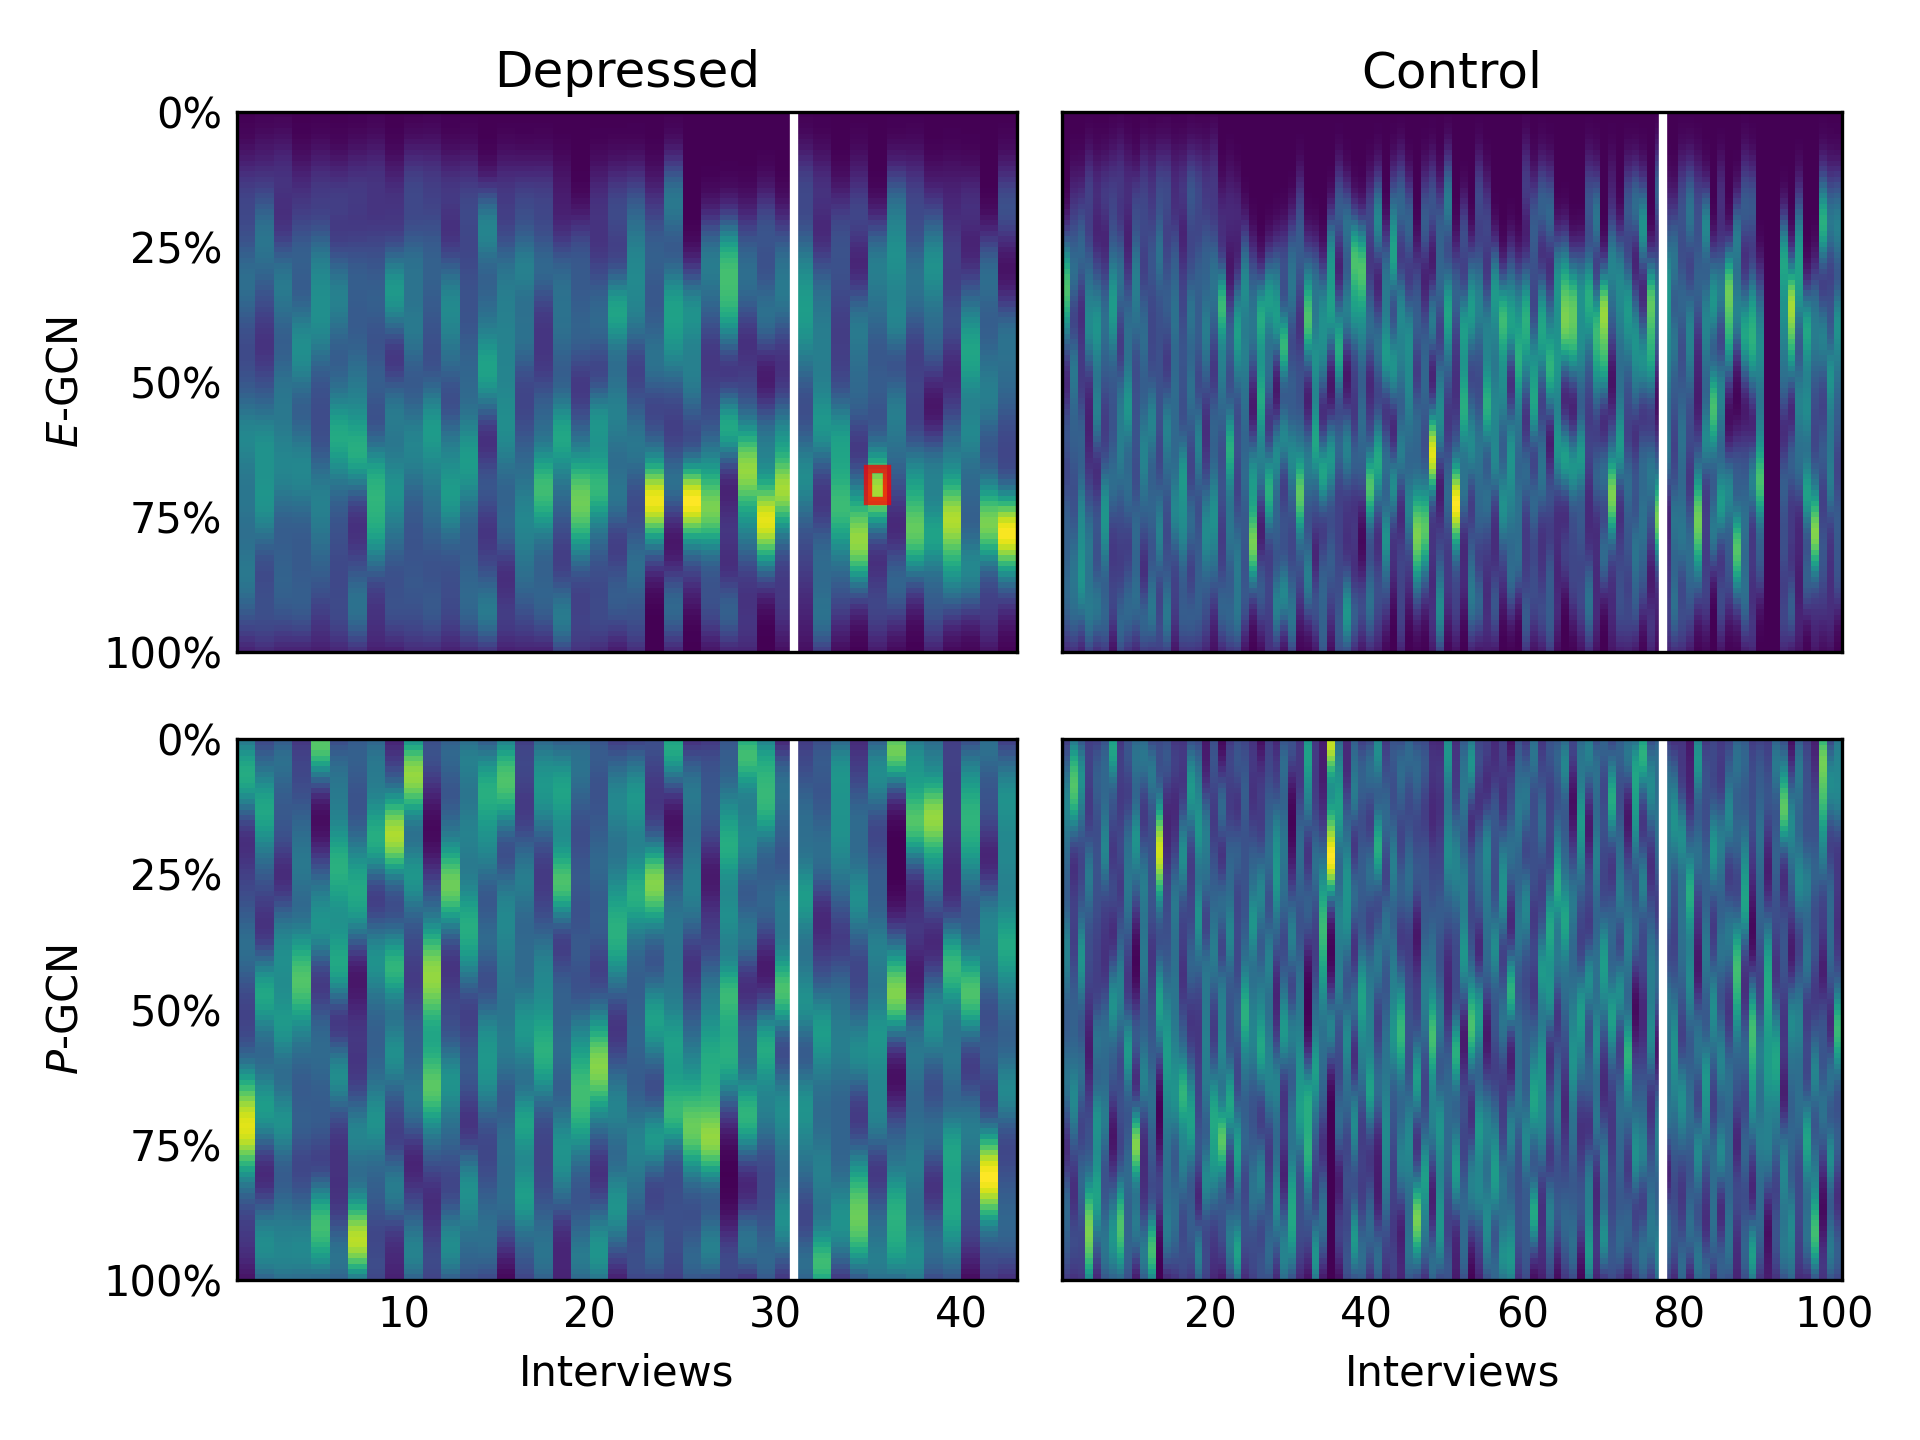

In [ ]:
# Display the saved heatmap
from IPython.display import Image
Image('plots/temporal_heatmap.png')

## 10. Generate Figure 2 — HTML Interview Visualisations (`figure_2_color_interviews.py`)

This script needs the raw DAIC-WOZ transcript CSV files (`<ID>_P/<ID>_TRANSCRIPT.csv`).
Set `DAIC_WOZ_RAW` to the folder on Drive that contains those per-interview folders.

In [ ]:
# Raw interview folders (300_P/, 301_P/, ...) live directly in DRIVE_DAIC_DIR
DAIC_WOZ_RAW = DRIVE_DAIC_DIR  # /content/drive/MyDrive/DAIC

# Spot-check: look for at least one <ID>_P folder
interview_folders = [d for d in os.listdir(DAIC_WOZ_RAW) if d.endswith('_P')]
if interview_folders:
    print(f'Found {len(interview_folders)} interview folder(s), e.g.: {interview_folders[:5]}')
    import subprocess
    result = subprocess.run(
        ['python', 'figure_2_color_interviews.py',
         '--daic-woz', DAIC_WOZ_RAW,
         '--target-ids', 'data/AVEC_16_data/dev_IDS.txt',
         '-w-e', 'output/Ellie/13_induct-gcn[original-features-1]/words.csv',
         '-w-p', 'output/Participant/21_induct-gcn[original-features250]/words.csv',
         '--output-folder', 'plots/html'],
        capture_output=False
    )
else:
    print('WARNING: No <ID>_P folders found in', DAIC_WOZ_RAW)
    print('Make sure your raw DAIC-WOZ interview folders are in MyDrive/DAIC/')

Found 189 interview folder(s), e.g.: ['341_P', '337_P', '338_P', '336_P', '345_P']


## 11. Resume a Previous Run

Because `output/` and `model/` are symlinked to Drive, Optuna studies persist between
Colab sessions. Re-running a task cell will **resume** the study from where it left off.

In [ ]:
# Quick check: list saved outputs on Drive
for root, dirs, files in os.walk('output'):
    for f in files:
        print(os.path.join(root, f))

output/Ellie/0_induct-gcn[pagerank-features-1]/induct-gcn-model-checkpoint.pkl
output/Ellie/0_induct-gcn[pagerank-features-1]/results_predictions.json
output/Ellie/0_induct-gcn[pagerank-features-1]/words.csv
output/Ellie/0_induct-gcn[pagerank-features-1]/CM-inducT-GCN(64)S17.png
output/Ellie/0_induct-gcn[pagerank-features-1]/results.json
output/Ellie/0_induct-gcn[pagerank-features-1]/db.sqlite3
output/Ellie/3_induct-gcn[original-features250]/results.json
output/Ellie/3_induct-gcn[original-features250]/words.csv
output/Ellie/3_induct-gcn[original-features250]/CM-inducT-GCN(64)S17.png
output/Ellie/3_induct-gcn[original-features250]/results_predictions.json
output/Ellie/3_induct-gcn[original-features250]/induct-gcn-model-checkpoint.pkl
output/Ellie/3_induct-gcn[original-features250]/db.sqlite3
output/Ellie/baseline/bs8/Ellie/db.sqlite3
output/Ellie/baseline/bs8/Ellie/best_results_predictions.json
output/Ellie/baseline/bs8/Ellie/run-1/checkpoint-56/config.json
output/Ellie/baseline/bs8/Ell

In [ ]:
import os
for root, dirs, files in os.walk('output'):
    if 'words.csv' in files:
        print(os.path.join(root, 'words.csv'))


output/Ellie/0_induct-gcn[pagerank-features-1]/words.csv
output/Ellie/3_induct-gcn[original-features250]/words.csv
output/Participant/11_induct-gcn[original-features0]/words.csv
output/Participant/9_induct-gcn[original-features250]/words.csv


In [ ]:
import os, pickle, torch, sys
sys.path.insert(0, '/content/bias-in-daic-woz')
from main import load_induct_gcn_model

# ── 1. Show all saved models ──────────────────────────────────────
print("Saved models on Drive:")
for root, dirs, files in os.walk('model'):
    for f in files:
        path = os.path.join(root, f)
        size = os.path.getsize(path) / 1024
        print(f"  {path}  ({size:.1f} KB)")

# ── 2. Load a specific model and run inference ────────────────────
# Update these paths to match your saved model files above
PATH_MODEL      = 'model/Ellie/0_induct-gcn[pagerank-features-1]/model_inductgcn[-1].pkl'
PATH_VECTORIZER = 'model/Ellie/0_induct-gcn[pagerank-features-1]/vtzer_inductgcn[-1].pkl'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = load_induct_gcn_model(PATH_MODEL, PATH_VECTORIZER, device=DEVICE)
model.eval()
print(f"\nModel loaded from: {PATH_MODEL}")
print(f"Classes: {model.classes_}")

import main as main_module
main_module.DEVICE = DEVICE   # inject the device into main.py's namespace

sample_text = "i feel very tired and have no motivation lately"
prediction = model.predict(sample_text)
proba = model.predict_proba(sample_text)
print(f"Input      : {sample_text}")
print(f"Prediction : {prediction}")
print(f"Probabilities: {dict(zip(model.classes_, proba))}")


# ── 3. Run prediction on new text ─────────────────────────────────
sample_text = "i feel very tired and have no motivation lately"
prediction = model.predict(sample_text)
proba = model.predict_proba(sample_text)
print(f"\nInput : {sample_text}")
print(f"Prediction : {prediction}")
print(f"Probabilities: {dict(zip(model.classes_, proba))}")


Saved models on Drive:
  model/Ellie/0_induct-gcn[pagerank-features-1]/vtzer_inductgcn[-1].pkl  (3.8 KB)
  model/Ellie/0_induct-gcn[pagerank-features-1]/model_inductgcn[-1].pkl  (475.2 KB)
  model/Ellie/3_induct-gcn[original-features250]/model_inductgcn[250].pkl  (1014.2 KB)
  model/Ellie/3_induct-gcn[original-features250]/vtzer_inductgcn[250].pkl  (6.5 KB)
  model/Participant/11_induct-gcn[original-features0]/model_inductgcn[0].pkl  (256356.4 KB)
  model/Participant/11_induct-gcn[original-features0]/vtzer_inductgcn[0].pkl  (116.0 KB)
  model/Participant/9_induct-gcn[original-features250]/model_inductgcn[250].pkl  (1014.2 KB)
  model/Participant/9_induct-gcn[original-features250]/vtzer_inductgcn[250].pkl  (6.2 KB)

Model loaded from: model/Ellie/0_induct-gcn[pagerank-features-1]/model_inductgcn[-1].pkl
Classes: ['negative', 'positive']
Input      : i feel very tired and have no motivation lately
Prediction : positive
Probabilities: {'negative': np.float32(0.45889708), 'positive': np.fl

Found 4 trained model(s):

  Ellie/0_induct-gcn[pagerank-features-1]
    Accuracy: 85.71%  |  Macro F1: 84.44%
  Ellie/3_induct-gcn[original-features250]
    Accuracy: 74.29%  |  Macro F1: 72.87%
  Participant/11_induct-gcn[original-features0]
    Accuracy: 65.71%  |  Macro F1: 51.39%
  Participant/9_induct-gcn[original-features250]
    Accuracy: 80.00%  |  Macro F1: 78.90%


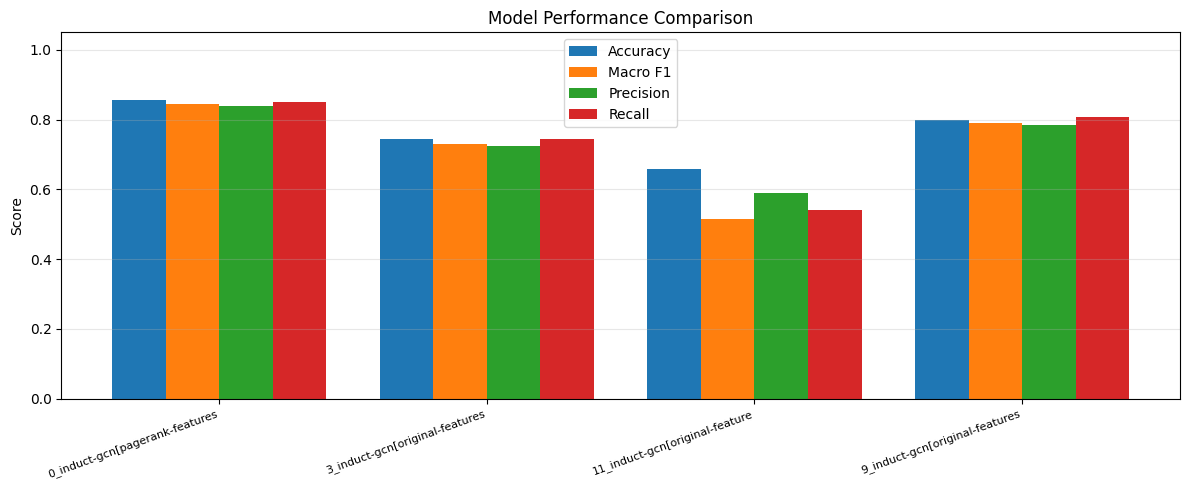

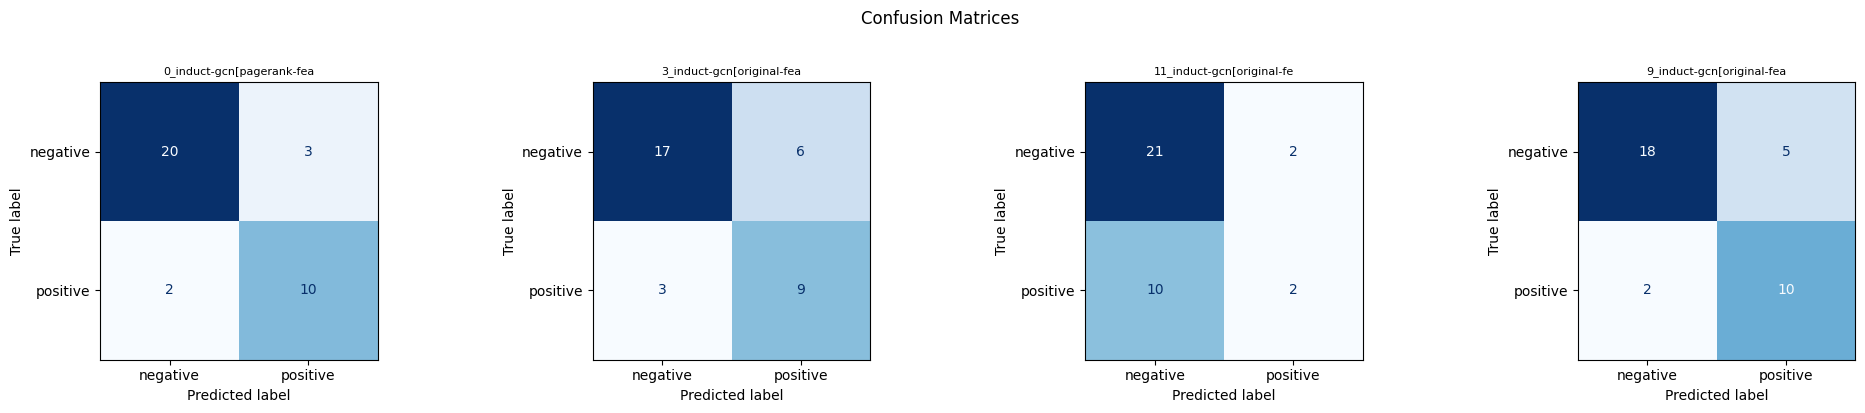

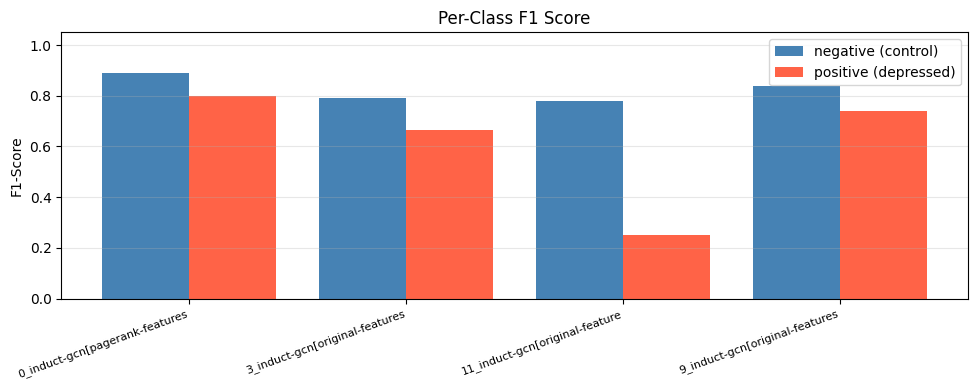



Ellie/0_induct-gcn[pagerank-features-1]
------------------------------------------------------------
              precision    recall  f1-score   support

    negative      0.909     0.870     0.889        23
    positive      0.769     0.833     0.800        12

    accuracy                          0.857        35
   macro avg      0.839     0.851     0.844        35
weighted avg      0.861     0.857     0.858        35


Ellie/3_induct-gcn[original-features250]
------------------------------------------------------------
              precision    recall  f1-score   support

    negative      0.850     0.739     0.791        23
    positive      0.600     0.750     0.667        12

    accuracy                          0.743        35
   macro avg      0.725     0.745     0.729        35
weighted avg      0.764     0.743     0.748        35


Participant/11_induct-gcn[original-features0]
------------------------------------------------------------
              precision    recal

In [ ]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)

# ── Collect all result files ──────────────────────────────────────
models = {}
for root, dirs, files in os.walk('output'):
    if 'results.json' in files and 'results_predictions.json' in files:
        with open(os.path.join(root, 'results.json')) as f:
            results = json.load(f)
        with open(os.path.join(root, 'results_predictions.json')) as f:
            preds = json.load(f)
        label = root.replace('output/', '')
        models[label] = {'results': results, 'preds': preds}

print(f"Found {len(models)} trained model(s):\n")
for name, m in models.items():
    f1 = m['results']['macro avg']['f1-score']
    acc = m['results']['accuracy']
    print(f"  {name}")
    print(f"    Accuracy: {acc:.2%}  |  Macro F1: {f1:.2%}")

# ── 1. F1 / Precision / Recall comparison bar chart ──────────────
labels_plot = [n.split('/')[-1][:30] for n in models]
metrics_data = {
    'Accuracy':  [m['results']['accuracy'] for m in models.values()],
    'Macro F1':  [m['results']['macro avg']['f1-score'] for m in models.values()],
    'Precision': [m['results']['macro avg']['precision'] for m in models.values()],
    'Recall':    [m['results']['macro avg']['recall'] for m in models.values()],
}

x = np.arange(len(labels_plot))
width = 0.2
fig, ax = plt.subplots(figsize=(max(10, len(models)*3), 5))
for i, (metric, vals) in enumerate(metrics_data.items()):
    ax.bar(x + i*width, vals, width, label=metric)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(labels_plot, rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150)
plt.show()

# ── 2. Confusion matrix for each model ───────────────────────────
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]
for ax, (name, m) in zip(axes, models.items()):
    y_true = m['preds']['y_true']
    y_pred = m['preds']['y_pred']
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name.split('/')[-1][:25], fontsize=8)
plt.suptitle('Confusion Matrices', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=150)
plt.show()

# ── 3. Per-class F1 breakdown (fixed) ───────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(models)*2.5), 4))
x = np.arange(len(models))

neg_f1, pos_f1 = [], []
for m in models.values():
    r = m['results']
    # results.json stores classes as "0" and "1"
    neg_f1.append(r.get('0', r.get('negative', {})).get('f1-score', 0))
    pos_f1.append(r.get('1', r.get('positive', {})).get('f1-score', 0))

ax.bar(x - 0.2, neg_f1, 0.4, label='negative (control)', color='steelblue')
ax.bar(x + 0.2, pos_f1, 0.4, label='positive (depressed)', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1 Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/per_class_f1.png', dpi=150)
plt.show()


# ── 4. Classification report table ───────────────────────────────
print("\n" + "="*60)
for name, m in models.items():
    print(f"\n{name}")
    print("-"*60)
    y_true = m['preds']['y_true']
    y_pred = m['preds']['y_pred']
    print(classification_report(y_true, y_pred,
                                target_names=['negative','positive'],
                                digits=3))

print("Plots saved to plots/ on Drive.")


## 12. Extended Visualizations\n\nRun the cells below for ROC curves, Precision-Recall curves, radar chart, word clouds, and top learned words.

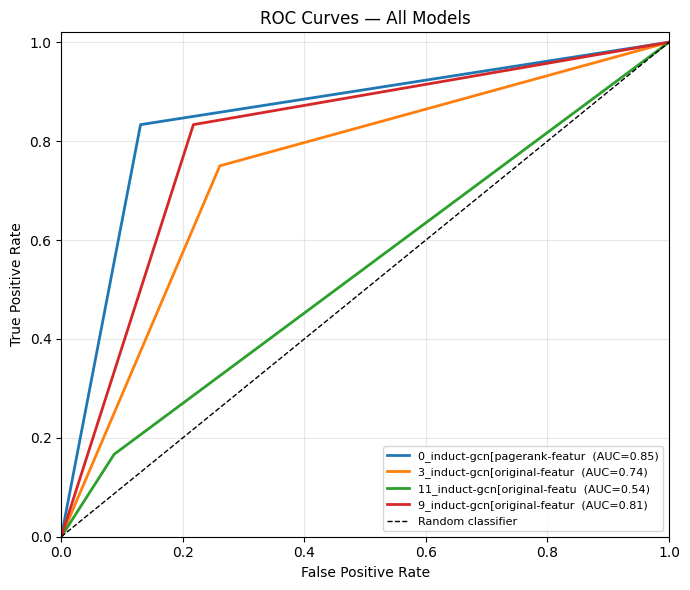

Saved → plots/roc_curves.png


In [ ]:
# ── 12a. ROC Curves ───────────────────────────────────────────────
import json, os, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models_vis = {}
for root, dirs, files in os.walk('output'):
    if 'results.json' in files and 'results_predictions.json' in files:
        with open(os.path.join(root, 'results.json')) as f:
            results = json.load(f)
        with open(os.path.join(root, 'results_predictions.json')) as f:
            preds = json.load(f)
        label = root.replace('output/', '')
        models_vis[label] = {'results': results, 'preds': preds}

fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.tab10.colors

for i, (name, m) in enumerate(models_vis.items()):
    y_true = np.array(m['preds']['y_true'])
    # Use probability of positive class if saved, otherwise fall back to binary predictions
    if 'y_prob' in m['preds']:
        y_score = np.array(m['preds']['y_prob'])
    else:
        y_score = np.array(m['preds']['y_pred'], dtype=float)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    short = name.split('/')[-1][:28]
    ax.plot(fpr, tpr, color=colors[i % 10], lw=2,
            label=f'{short}  (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=150)
plt.show()
print('Saved → plots/roc_curves.png')

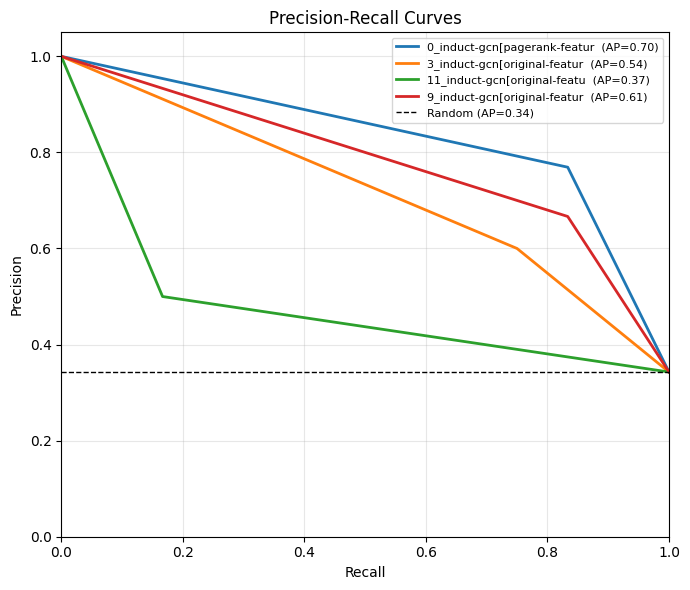

Saved → plots/pr_curves.png


In [ ]:
# ── 12b. Precision-Recall Curves ─────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 6))

for i, (name, m) in enumerate(models_vis.items()):
    y_true = np.array(m['preds']['y_true'])
    if 'y_prob' in m['preds']:
        y_score = np.array(m['preds']['y_prob'])
    else:
        y_score = np.array(m['preds']['y_pred'], dtype=float)

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    short = name.split('/')[-1][:28]
    ax.plot(recall, precision, color=colors[i % 10], lw=2,
            label=f'{short}  (AP={ap:.2f})')

# Baseline: fraction of positives
pos_rate = sum(np.array(list(models_vis.values())[0]['preds']['y_true'])) / len(list(models_vis.values())[0]['preds']['y_true'])
ax.axhline(y=pos_rate, color='k', linestyle='--', lw=1, label=f'Random (AP={pos_rate:.2f})')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/pr_curves.png', dpi=150)
plt.show()
print('Saved → plots/pr_curves.png')

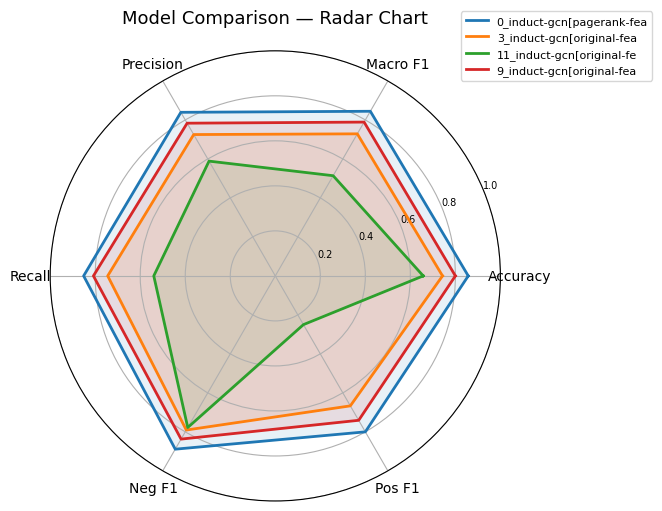

Saved → plots/radar_chart.png


In [ ]:
# ── 12c. Radar / Spider Chart — multi-metric model comparison ─────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

metric_names = ['Accuracy', 'Macro F1', 'Precision', 'Recall',
                'Neg F1', 'Pos F1']

def get_radar_vals(m):
    r = m['results']
    neg_f1 = r.get('0', r.get('negative', {})).get('f1-score', 0)
    pos_f1 = r.get('1', r.get('positive', {})).get('f1-score', 0)
    return [
        r['accuracy'],
        r['macro avg']['f1-score'],
        r['macro avg']['precision'],
        r['macro avg']['recall'],
        neg_f1,
        pos_f1,
    ]

N = len(metric_names)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors_r = plt.cm.tab10.colors

for i, (name, m) in enumerate(models_vis.items()):
    vals = get_radar_vals(m)
    vals += vals[:1]
    ax.plot(angles, vals, color=colors_r[i % 10], lw=2,
            label=name.split('/')[-1][:25])
    ax.fill(angles, vals, color=colors_r[i % 10], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7)
ax.set_title('Model Comparison — Radar Chart', pad=20, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig('plots/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plots/radar_chart.png')

Found 4 words.csv file(s)


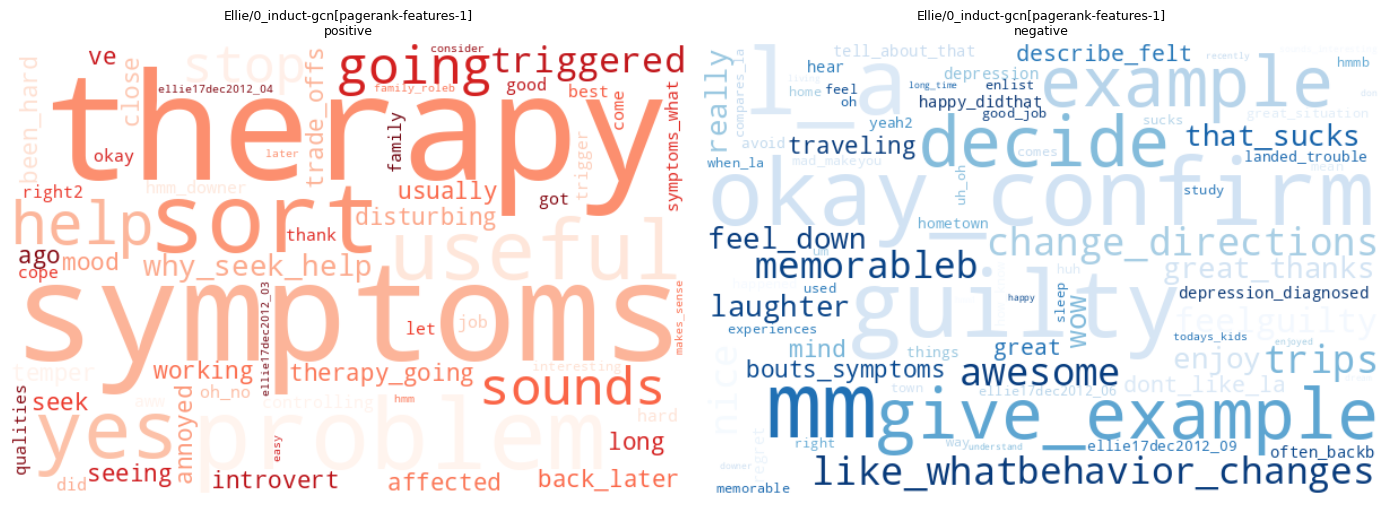

  Saved → plots/wordcloud_Ellie_0_induct-gcn[pagerank-features-1].png


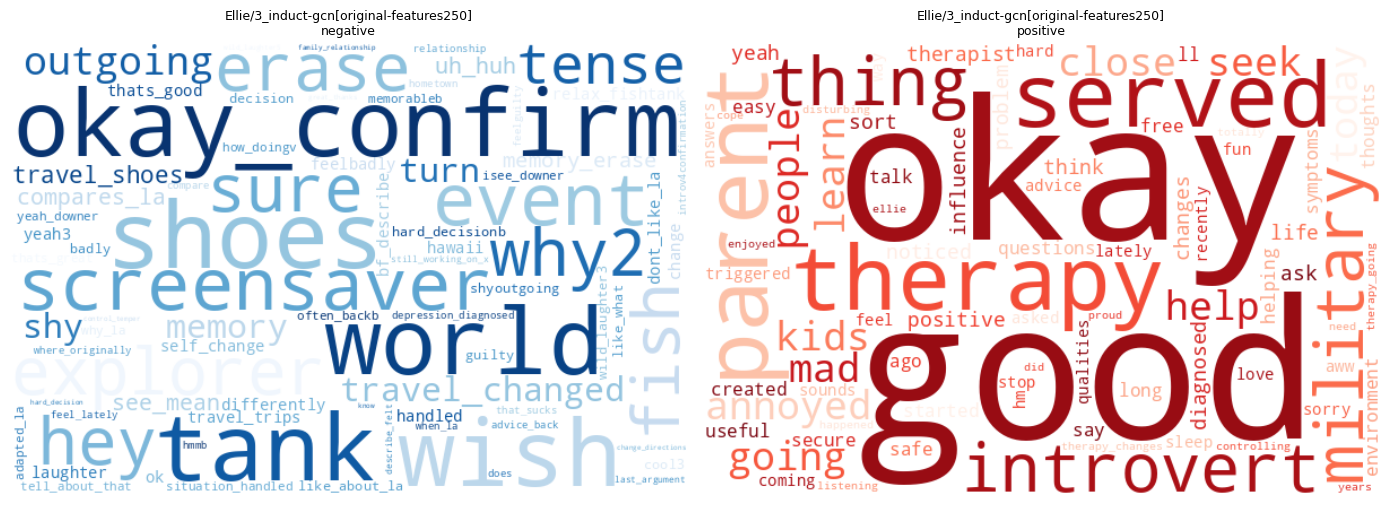

  Saved → plots/wordcloud_Ellie_3_induct-gcn[original-features250].png


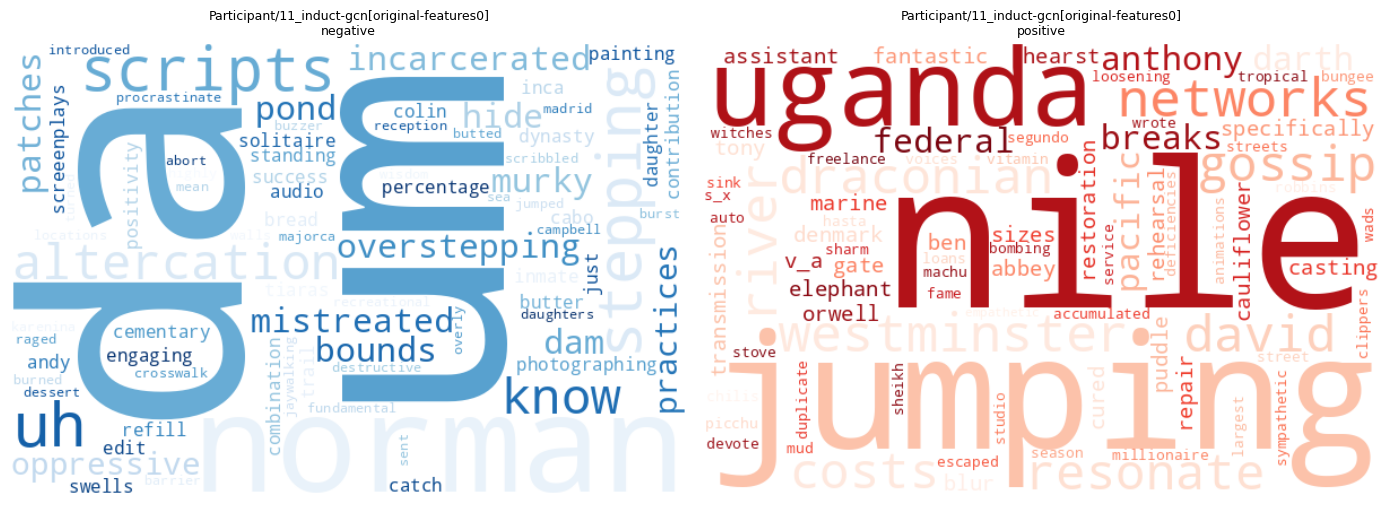

  Saved → plots/wordcloud_Participant_11_induct-gcn[original-features0].png


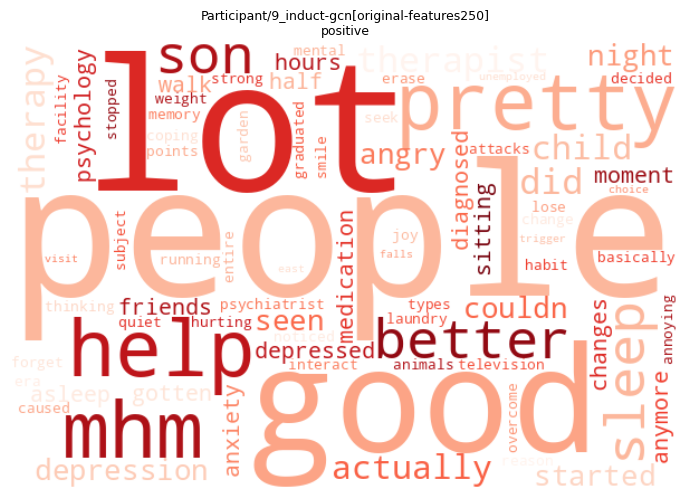

  Saved → plots/wordcloud_Participant_9_induct-gcn[original-features250].png


In [ ]:
# ── 12d. Word Clouds ─────────────────────────────────────────────
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', '-q', 'wordcloud'], check=True)
    from wordcloud import WordCloud
import pandas as pd

words_files = []
for root, dirs, files in os.walk('output'):
    for f in files:
        if f == 'words.csv':
            words_files.append(os.path.join(root, f))

print(f"Found {len(words_files)} words.csv file(s)")

for words_path in words_files:
    model_name = words_path.replace('output/', '').replace('/words.csv', '')
    # No header: columns are  word | label | weight
    df = pd.read_csv(words_path, header=None, names=['word', 'label', 'weight'])
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce').fillna(0)

    labels = df['label'].unique()
    fig, axes = plt.subplots(1, len(labels), figsize=(7 * len(labels), 5))
    if len(labels) == 1: axes = [axes]

    for ax, lbl in zip(axes, labels):
        sub = df[df['label'] == lbl]
        freq = dict(zip(sub['word'].astype(str), sub['weight']))
        freq = {w: v for w, v in freq.items() if v > 0}
        if not freq:
            ax.text(0.5, 0.5, 'No data', ha='center'); ax.axis('off'); continue
        color = 'Reds' if 'pos' in str(lbl).lower() else 'Blues'
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=color, max_words=80).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
        ax.set_title(f'{model_name}\n{lbl}', fontsize=9)

    out_path = f"plots/wordcloud_{model_name.replace('/', '_')}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {out_path}')


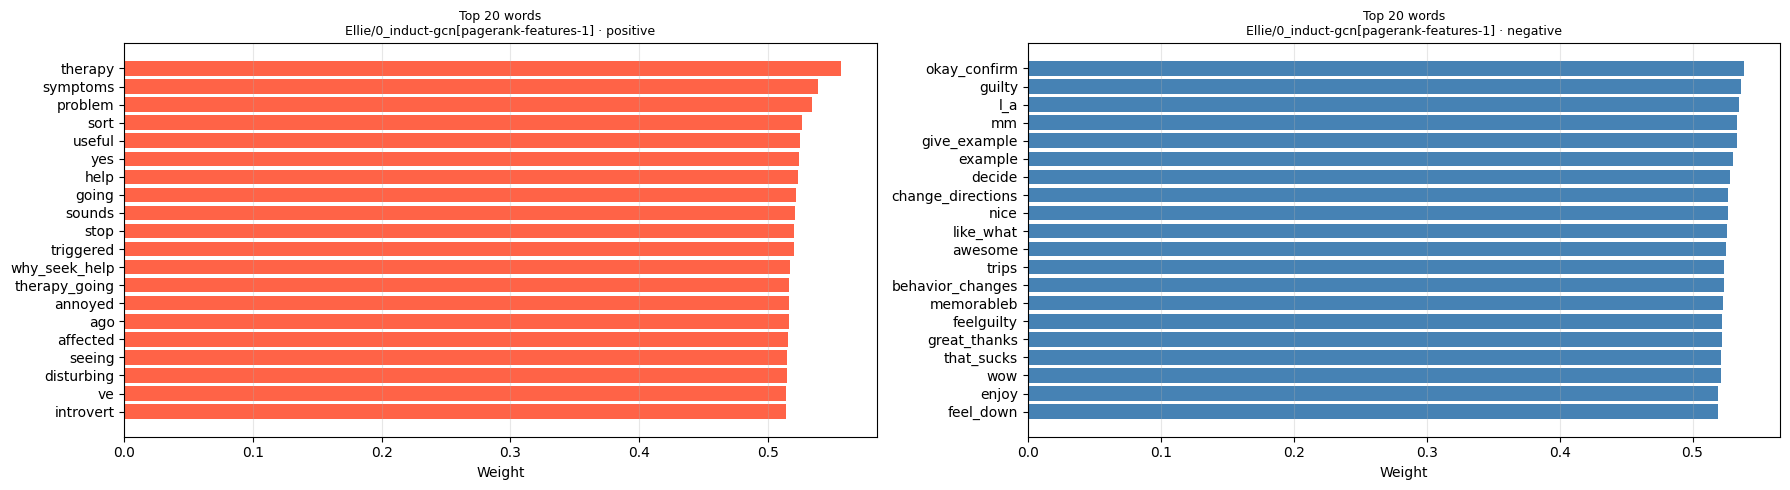

Saved → plots/top_words_Ellie_0_induct-gcn[pagerank-features-1].png


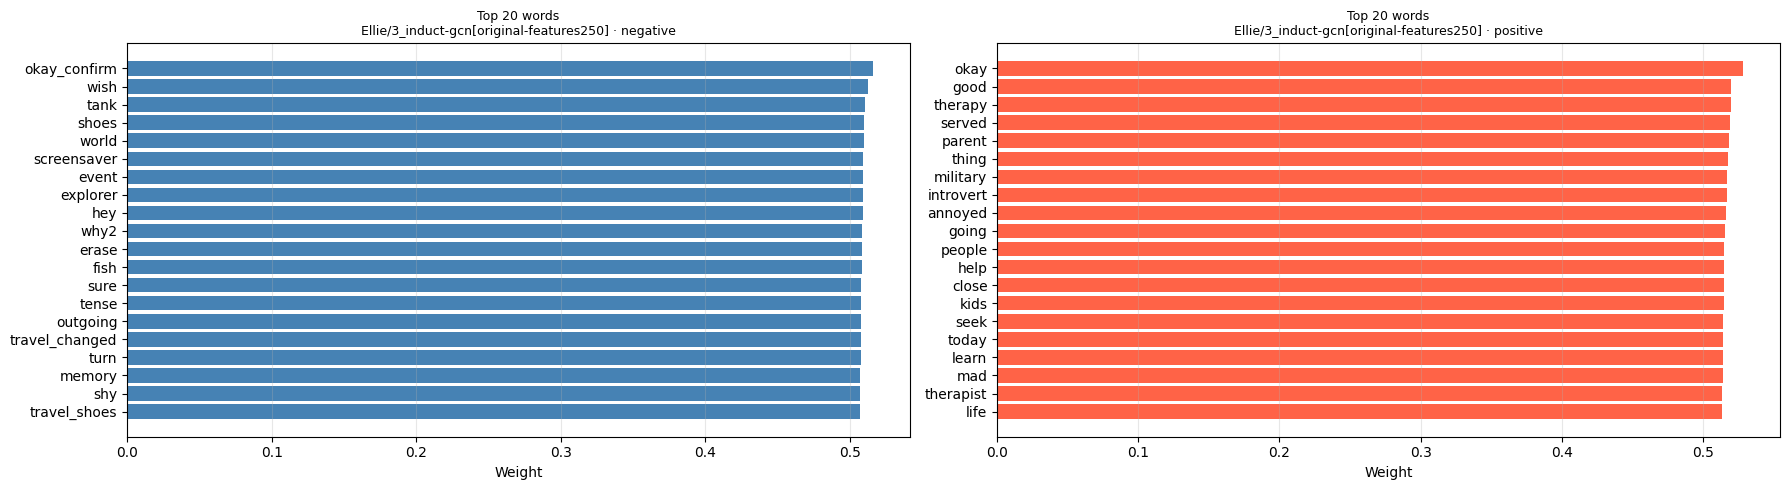

Saved → plots/top_words_Ellie_3_induct-gcn[original-features250].png


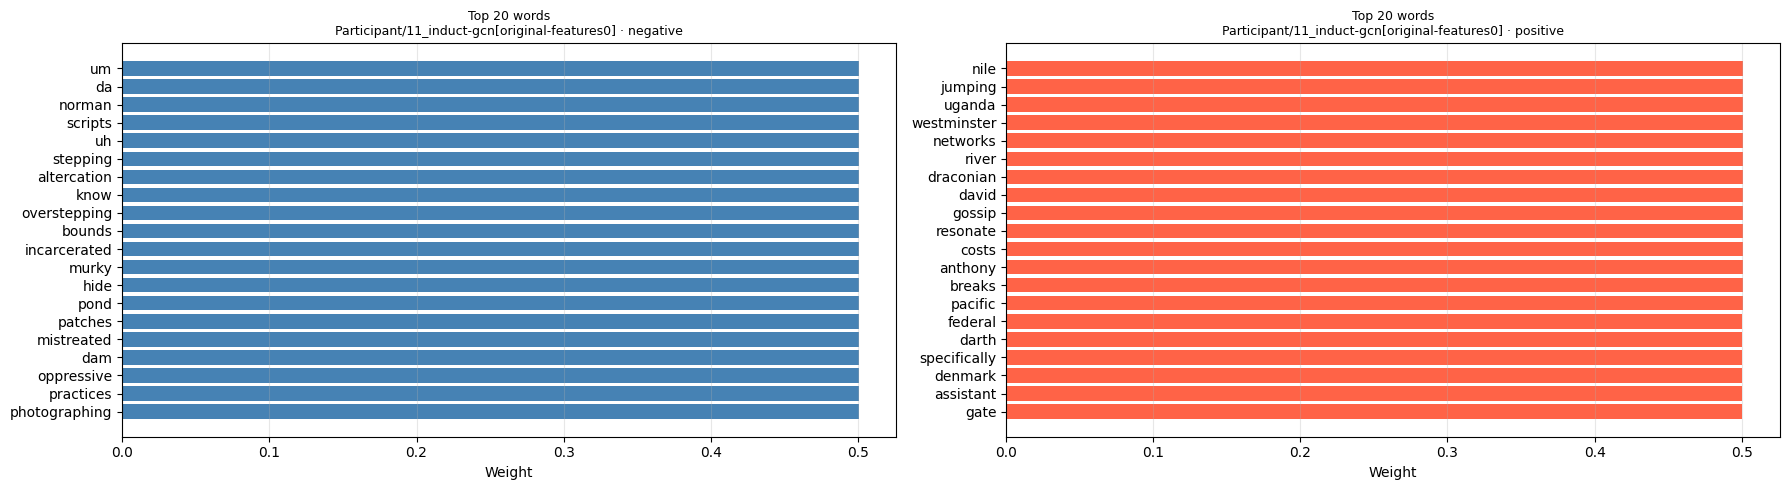

Saved → plots/top_words_Participant_11_induct-gcn[original-features0].png


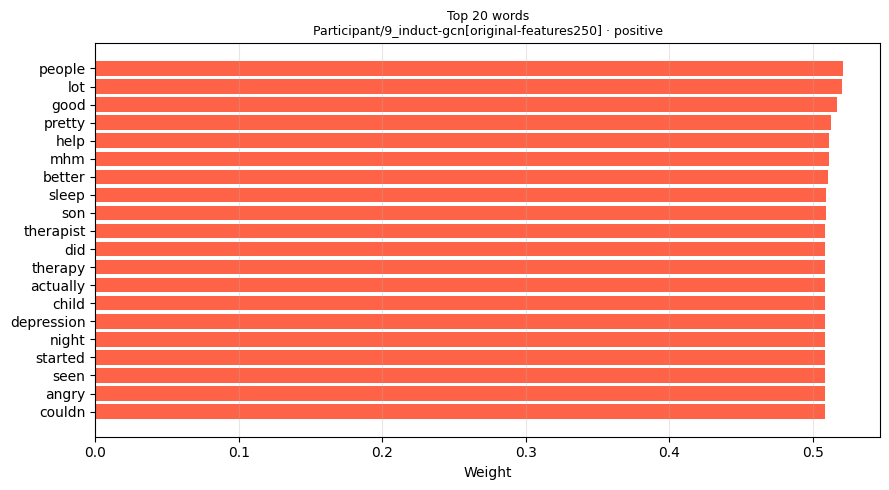

Saved → plots/top_words_Participant_9_induct-gcn[original-features250].png


In [ ]:
# ── 12e. Top-20 Learned Words Bar Chart ──────────────────────────
import pandas as pd
TOP_N = 20

words_files = []
for root, dirs, files in os.walk('output'):
    for f in files:
        if f == 'words.csv':
            words_files.append(os.path.join(root, f))

for words_path in words_files:
    model_name = words_path.replace('output/', '').replace('/words.csv', '')
    # No header: columns are  word | label | weight
    df = pd.read_csv(words_path, header=None, names=['word', 'label', 'weight'])
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce').fillna(0)

    labels = df['label'].unique()
    fig, axes = plt.subplots(1, len(labels), figsize=(9 * len(labels), 5))
    if len(labels) == 1: axes = [axes]

    for ax, lbl in zip(axes, labels):
        sub = df[(df['label'] == lbl) & (df['weight'] > 0)].nlargest(TOP_N, 'weight')
        color = 'tomato' if 'pos' in str(lbl).lower() else 'steelblue'
        ax.barh(sub['word'].astype(str), sub['weight'], color=color)
        ax.invert_yaxis()
        ax.set_xlabel('Weight')
        ax.set_title(f'Top {TOP_N} words\n{model_name} · {lbl}', fontsize=9)
        ax.grid(axis='x', alpha=0.3)

    out_path = f"plots/top_words_{model_name.replace('/', '_')}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')
